In [37]:
import fitz  
import re
import string
import pandas as pd

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

import plotly.express as px

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


In [38]:

pdf = fitz.open("Pride.pdf")  

# Extract text
text = ""

for page in pdf:
    text += page.get_text()

# Total pages
print("Total pages:", pdf.page_count)

# Sample text
print("\nSample text:\n")
print(text[:1000])

Total pages: 538

Sample text:

 
Pride and Prejudice 
 
 
By Jane Austen 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
Ebd 
E-BooksDirectory.com 
 
 
Chapter 1.  
It is a truth universally acknowledged, that a single man in 
possession of a good fortune, must be in want of a wife.  
However little known the feelings or views of such a man 
may be on his first entering a neighbourhood, this truth is so 
well fixed in the minds of the surrounding families, that he is 
considered the rightful property of some one or other of their 
daughters.  
"My dear Mr. Bennet," said his lady to him one day, "have 
you heard that Netherfield Park is let at last?"  
Mr. Bennet replied that he had not.  
"But it is," returned she; "for Mrs. Long has just been here, 
and she told me all about it."  
Mr. Bennet made no answer.  
"Do you not want to know who has taken it?" cried his 
wife impatiently.  
"You want to tell me, and I have no objection to hearing 
it."  
This was invitation enough.  
"Why, my dear, you mu

In [39]:
# Lowercase
text = text.lower()

# Remove numbers (Regex)
text = re.sub(r'\d+', '', text)

# Remove special characters (Regex)
text = re.sub(r'[^a-z\s]', '', text)

# Remove extra spaces (Regex)
text = re.sub(r'\s+', ' ', text).strip()

# Tokenization
words = text.split()

# Stopwords
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w not in stop_words]

# Counts
print("Total words:", len(words))
print("Stopwords removed:", len(words) - len(filtered_words))
print("Valid words:", len(filtered_words))

Total words: 121586
Stopwords removed: 66584
Valid words: 55002


In [40]:
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(w) for w in filtered_words]

print("Sample stemmed words:", stemmed_words[:20])

Sample stemmed words: ['pride', 'prejudic', 'jane', 'austen', 'ebd', 'ebooksdirectorycom', 'chapter', 'truth', 'univers', 'acknowledg', 'singl', 'man', 'possess', 'good', 'fortun', 'must', 'want', 'wife', 'howev', 'littl']


In [41]:
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(w) for w in filtered_words]

print("Sample lemmatized words:", lemmatized_words[:20])

Sample lemmatized words: ['pride', 'prejudice', 'jane', 'austen', 'ebd', 'ebooksdirectorycom', 'chapter', 'truth', 'universally', 'acknowledged', 'single', 'man', 'possession', 'good', 'fortune', 'must', 'want', 'wife', 'however', 'little']


In [42]:
unique_words = list(set(lemmatized_words))

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform([[w] for w in unique_words])

df_onehot = pd.DataFrame(encoded, index=unique_words)

print(df_onehot.head(10))

              0     1     2     3     4     5     6     7     8     9     ...  \
haye           0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
staredmany     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
prefer         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
attempted      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
together       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
precipitance   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
relationship   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
hotpressed     0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
wandered       0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
unavoidable    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   

              6055  6056  6057  6058  6059  6060  6061  6062  6063  6064  
haye           0.0   0.0   0.0   

In [43]:
# Convert list back to string
final_text = " ".join(lemmatized_words)

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform([final_text])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(df_tfidf)

   abatement  abhorrence  abhorrent     abide   abiding   ability      able  \
0   0.000413    0.002479   0.000413  0.000413  0.000413  0.002479  0.022728   

   ablution     abode  abominable  ...    youbut    youhow     youll  \
0  0.000413  0.003306    0.002479  ...  0.000826  0.000413  0.000413   

      youmr     young    younge   younger  youngest  yourselfand     youth  
0  0.000413  0.053306  0.001653  0.012397  0.005372     0.000413  0.004132  

[1 rows x 6057 columns]


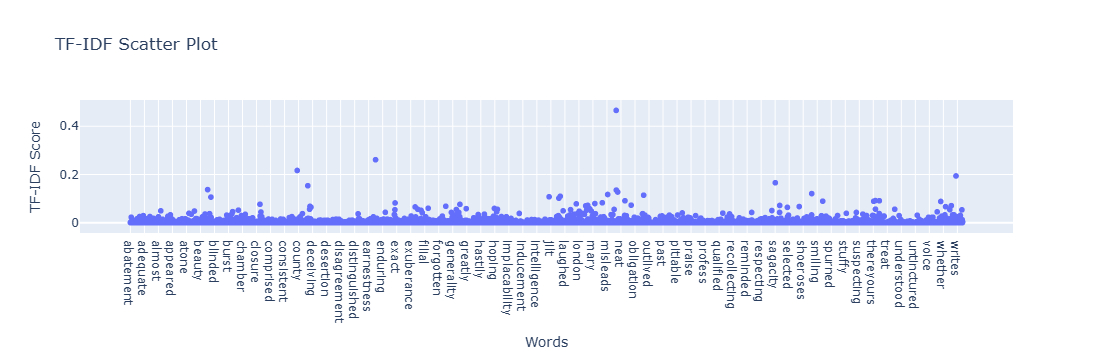

In [44]:
tfidf_values = df_tfidf.iloc[0]

df_plot = pd.DataFrame({
    "word": tfidf_values.index,
    "tfidf": tfidf_values.values
})

fig = px.scatter(
    df_plot,
    x="word",
    y="tfidf",
    title="TF-IDF Scatter Plot",
    labels={"word": "Words", "tfidf": "TF-IDF Score"}
)

fig.show()